In [1]:
from pathlib import Path

PROJECT_ROOT = Path(r"C:\Users\ZEUS\Documents\carbon_aware_marine_ai")

DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
PROCESSED_DATA_DIR = DATA_DIR / "processed"

OUTPUTS_DIR = PROJECT_ROOT / "outputs"
METRICS_DIR = OUTPUTS_DIR / "metrics"
EMISSIONS_DIR = OUTPUTS_DIR / "emissions"
CLOUD_SIM_DIR = OUTPUTS_DIR / "cloud_simulation"
MODELS_DIR = OUTPUTS_DIR / "models"

FIGURES_DIR = PROJECT_ROOT / "figures"

for folder in [
    RAW_DATA_DIR,
    PROCESSED_DATA_DIR,
    METRICS_DIR,
    EMISSIONS_DIR,
    CLOUD_SIM_DIR,
    MODELS_DIR,
    FIGURES_DIR
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Metrics folder:", METRICS_DIR)
print("Emissions folder:", EMISSIONS_DIR)
print("Cloud simulation folder:", CLOUD_SIM_DIR)
print("Figures folder:", FIGURES_DIR)

Project root: C:\Users\ZEUS\Documents\carbon_aware_marine_ai
Metrics folder: C:\Users\ZEUS\Documents\carbon_aware_marine_ai\outputs\metrics
Emissions folder: C:\Users\ZEUS\Documents\carbon_aware_marine_ai\outputs\emissions
Cloud simulation folder: C:\Users\ZEUS\Documents\carbon_aware_marine_ai\outputs\cloud_simulation
Figures folder: C:\Users\ZEUS\Documents\carbon_aware_marine_ai\figures


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [3]:
metrics_file_path = METRICS_DIR / "model_metrics_south_florida_atlantic_2021_2024.csv"

print("Metrics file path:")
print(metrics_file_path)
print("File exists:", metrics_file_path.exists())

if not metrics_file_path.exists():
    raise FileNotFoundError("Model metrics file was not found. Please check Notebook 04 output.")

model_metrics_df = pd.read_csv(metrics_file_path)

# Making sure clearer emissions units exist
if "emissions_g_co2eq" not in model_metrics_df.columns:
    model_metrics_df["emissions_g_co2eq"] = model_metrics_df["emissions_kg_co2eq"] * 1000

if "emissions_mg_co2eq" not in model_metrics_df.columns:
    model_metrics_df["emissions_mg_co2eq"] = model_metrics_df["emissions_kg_co2eq"] * 1_000_000

print("Model metrics loaded successfully.")
print("Shape:", model_metrics_df.shape)

model_metrics_df

Metrics file path:
C:\Users\ZEUS\Documents\carbon_aware_marine_ai\outputs\metrics\model_metrics_south_florida_atlantic_2021_2024.csv
File exists: True
Model metrics loaded successfully.
Shape: (5, 9)


,model,mae,rmse,r2,training_time_seconds,emissions_kg_co2eq,emissions_g_co2eq,emissions_mg_co2eq,rmse_improvement_vs_persistence_percent
0,Ridge_Regression,0.098404,0.133645,0.995755,0.003660,0.000007,0.006717,6.716941,7.918419
1,Persistence_Baseline,0.108254,0.145137,0.994993,0.000221,0.000000,0.000000,0.000000,0.000000
2,Random_Forest,0.111861,0.152920,0.994442,2.084318,0.000038,0.038448,38.448187,-5.362477
3,XGBoost,0.118211,0.162210,0.993746,0.294449,0.000010,0.010432,10.431504,-11.763159
4,PyTorch_Neural_Network,0.727307,0.910292,0.803057,10.034340,0.000104,0.104310,104.309606,-527.192698


In [4]:
# Loading CodeCarbon emissions CSV files created in Notebook 04
emissions_files = sorted(EMISSIONS_DIR.glob("emissions_*.csv"))

print("CodeCarbon files found:")
for file_path in emissions_files:
    print(file_path.name)

if len(emissions_files) == 0:
    print("No CodeCarbon emissions files found. We will estimate energy from emissions as fallback.")

CodeCarbon files found:
emissions_pytorch_neural_network.csv
emissions_random_forest.csv
emissions_ridge_regression.csv
emissions_xgboost.csv


In [5]:
def model_name_from_emissions_file(file_path):
    """
    Converting CodeCarbon emissions filename into the model name used in model_metrics_df.
    """
    file_stem = file_path.stem.replace("emissions_", "")

    name_map = {
        "ridge_regression": "Ridge_Regression",
        "random_forest": "Random_Forest",
        "xgboost": "XGBoost",
        "pytorch_neural_network": "PyTorch_Neural_Network"
    }

    return name_map.get(file_stem, file_stem)


energy_rows = []

for file_path in emissions_files:
    emissions_df = pd.read_csv(file_path)

    # CodeCarbon usually appends one row per run. The last row is the latest run.
    latest_row = emissions_df.iloc[-1].to_dict()

    model_name = model_name_from_emissions_file(file_path)

    energy_kwh = latest_row.get("energy_consumed", np.nan)
    emissions_kg = latest_row.get("emissions", np.nan)
    duration_seconds = latest_row.get("duration", np.nan)

    energy_rows.append({
        "model": model_name,
        "codecarbon_file": file_path.name,
        "measured_energy_kwh": energy_kwh,
        "codecarbon_emissions_kg": emissions_kg,
        "codecarbon_duration_seconds": duration_seconds
    })

energy_df = pd.DataFrame(energy_rows)

print("Extracted CodeCarbon energy data:")
energy_df

Extracted CodeCarbon energy data:


,model,codecarbon_file,measured_energy_kwh,codecarbon_emissions_kg,codecarbon_duration_seconds
0,PyTorch_Neural_Network,emissions_pytorch_neural_network.csv,0.000225,0.000104,11.537696
1,Random_Forest,emissions_random_forest.csv,0.000083,0.000038,3.592699
2,Ridge_Regression,emissions_ridge_regression.csv,0.000014,0.000007,1.514861
3,XGBoost,emissions_xgboost.csv,0.000022,0.000010,1.798660


In [6]:
carbon_model_df = model_metrics_df.merge(
    energy_df,
    on="model",
    how="left"
)

# Persistence baseline does not train, so its measured energy is zero.
carbon_model_df["measured_energy_kwh"] = carbon_model_df["measured_energy_kwh"].fillna(0.0)

# If CodeCarbon energy is missing for any trained model, estimate energy from emissions.
# This fallback is only used when energy_consumed is unavailable.
# 400 gCO2/kWh is used only as a rough fallback conversion, not as a final carbon result.
fallback_carbon_intensity_g_per_kwh = 400

needs_fallback = (
    (carbon_model_df["measured_energy_kwh"] == 0)
    & (carbon_model_df["emissions_kg_co2eq"] > 0)
)

carbon_model_df.loc[needs_fallback, "measured_energy_kwh"] = (
    carbon_model_df.loc[needs_fallback, "emissions_kg_co2eq"] * 1000
) / fallback_carbon_intensity_g_per_kwh

# Creating readable units
carbon_model_df["measured_energy_wh"] = carbon_model_df["measured_energy_kwh"] * 1000

carbon_model_output_path = CLOUD_SIM_DIR / "model_energy_emissions_summary.csv"
carbon_model_df.to_csv(carbon_model_output_path, index=False)

print("Model energy and emissions summary saved to:")
print(carbon_model_output_path)
print("File exists:", carbon_model_output_path.exists())

carbon_model_df

Model energy and emissions summary saved to:
C:\Users\ZEUS\Documents\carbon_aware_marine_ai\outputs\cloud_simulation\model_energy_emissions_summary.csv
File exists: True


,model,mae,rmse,r2,training_time_seconds,emissions_kg_co2eq,emissions_g_co2eq,emissions_mg_co2eq,rmse_improvement_vs_persistence_percent,codecarbon_file,measured_energy_kwh,codecarbon_emissions_kg,codecarbon_duration_seconds,measured_energy_wh
0,Ridge_Regression,0.098404,0.133645,0.995755,0.003660,0.000007,0.006717,6.716941,7.918419,emissions_ridge_regression.csv,0.000014,0.000007,1.514861,0.014458
1,Persistence_Baseline,0.108254,0.145137,0.994993,0.000221,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,NaN,NaN,0.000000
2,Random_Forest,0.111861,0.152920,0.994442,2.084318,0.000038,0.038448,38.448187,-5.362477,emissions_random_forest.csv,0.000083,0.000038,3.592699,0.082761
3,XGBoost,0.118211,0.162210,0.993746,0.294449,0.000010,0.010432,10.431504,-11.763159,emissions_xgboost.csv,0.000022,0.000010,1.798660,0.022454
4,PyTorch_Neural_Network,0.727307,0.910292,0.803057,10.034340,0.000104,0.104310,104.309606,-527.192698,emissions_pytorch_neural_network.csv,0.000225,0.000104,11.537696,0.224529


In [7]:
# Google Cloud public region carbon data for 2024
gcp_region_carbon_url = "https://raw.githubusercontent.com/GoogleCloudPlatform/region-carbon-info/main/data/yearly/2024.csv"

gcp_carbon_df = pd.read_csv(gcp_region_carbon_url)

print("Google Cloud region carbon data loaded.")
print("Shape:", gcp_carbon_df.shape)
print("Columns:", list(gcp_carbon_df.columns))

gcp_carbon_df.head()

Google Cloud region carbon data loaded.
Shape: (44, 4)
Columns: ['Google Cloud Region', 'Location', 'Google CFE', 'Grid carbon intensity (gCO2eq / kWh)']


,Google Cloud Region,Location,Google CFE,Grid carbon intensity (gCO2eq / kWh)
0,africa-south1,Johannesburg,0.15,656.85
1,asia-east1,Taiwan,0.17,439.29
2,asia-east2,Hong Kong,0.01,505.02
3,asia-northeast1,Tokyo,0.17,452.85
4,asia-northeast2,Osaka,0.46,296.19


In [8]:
# Renaming columns into clean names
gcp_carbon_df = gcp_carbon_df.rename(columns={
    "Google Cloud Region": "cloud_region",
    "Location": "location",
    "Google CFE": "google_cfe",
    "Grid carbon intensity (gCO2eq / kWh)": "grid_carbon_intensity_gco2eq_per_kwh"
})

# Cleaning numeric values
gcp_carbon_df["google_cfe"] = pd.to_numeric(gcp_carbon_df["google_cfe"], errors="coerce")
gcp_carbon_df["grid_carbon_intensity_gco2eq_per_kwh"] = pd.to_numeric(
    gcp_carbon_df["grid_carbon_intensity_gco2eq_per_kwh"],
    errors="coerce"
)

# Adding percent version for readability
gcp_carbon_df["google_cfe_percent"] = gcp_carbon_df["google_cfe"] * 100

# Sorting by grid carbon intensity, lower is cleaner
gcp_carbon_df = gcp_carbon_df.sort_values(
    "grid_carbon_intensity_gco2eq_per_kwh"
).reset_index(drop=True)

gcp_carbon_output_path = CLOUD_SIM_DIR / "gcp_region_carbon_data_2024_cleaned.csv"
gcp_carbon_df.to_csv(gcp_carbon_output_path, index=False)

print("Cleaned GCP carbon data saved to:")
print(gcp_carbon_output_path)
print("File exists:", gcp_carbon_output_path.exists())

gcp_carbon_df.head(10)

Cleaned GCP carbon data saved to:
C:\Users\ZEUS\Documents\carbon_aware_marine_ai\outputs\cloud_simulation\gcp_region_carbon_data_2024_cleaned.csv
File exists: True


,cloud_region,location,google_cfe,grid_carbon_intensity_gco2eq_per_kwh,google_cfe_percent
0,europe-north2,Stockholm,1.00,2.73,100.0
1,northamerica-northeast1,Montréal,0.99,5.48,99.0
2,europe-west6,Zürich,0.98,15.05,98.0
3,europe-west9,Paris,0.96,16.30,96.0
4,europe-north1,Finland,0.98,39.32,98.0
5,northamerica-northeast2,Toronto,0.84,58.56,84.0
6,southamerica-east1,Sāo Paulo,0.88,67.32,88.0
7,us-west1,Oregon,0.87,79.23,87.0
8,europe-southwest1,Madrid,0.87,89.04,87.0
9,europe-west1,Belgium,0.84,103.37,84.0


In [9]:
selected_region_names = [
    "us-east1",                  # South Carolina
    "us-east4",                  # Northern Virginia
    "us-west1",                  # Oregon
    "northamerica-northeast1",   # Montréal
    "europe-north2",             # Stockholm
    "europe-west6",              # Zürich
    "asia-south1"                # Mumbai, high-carbon comparison
]

selected_regions_df = gcp_carbon_df[
    gcp_carbon_df["cloud_region"].isin(selected_region_names)
].copy()

selected_regions_df = selected_regions_df.sort_values(
    "grid_carbon_intensity_gco2eq_per_kwh"
).reset_index(drop=True)

selected_regions_output_path = CLOUD_SIM_DIR / "selected_cloud_regions_for_simulation.csv"
selected_regions_df.to_csv(selected_regions_output_path, index=False)

print("Selected cloud regions saved to:")
print(selected_regions_output_path)
print("File exists:", selected_regions_output_path.exists())

selected_regions_df

Selected cloud regions saved to:
C:\Users\ZEUS\Documents\carbon_aware_marine_ai\outputs\cloud_simulation\selected_cloud_regions_for_simulation.csv
File exists: True


,cloud_region,location,google_cfe,grid_carbon_intensity_gco2eq_per_kwh,google_cfe_percent
0,europe-north2,Stockholm,1.00,2.73,100.0
1,northamerica-northeast1,Montréal,0.99,5.48,99.0
2,europe-west6,Zürich,0.98,15.05,98.0
3,us-west1,Oregon,0.87,79.23,87.0
4,us-east4,Northern Virginia,0.62,323.05,62.0
5,us-east1,South Carolina,0.31,575.77,31.0
6,asia-south1,Mumbai,0.09,678.76,9.0


In [10]:
simulation_rows = []

for _, model_row in carbon_model_df.iterrows():
    for _, region_row in selected_regions_df.iterrows():
        energy_kwh = model_row["measured_energy_kwh"]
        grid_intensity = region_row["grid_carbon_intensity_gco2eq_per_kwh"]

        simulated_emissions_kg = (energy_kwh * grid_intensity) / 1000

        simulation_rows.append({
            "model": model_row["model"],
            "mae": model_row["mae"],
            "rmse": model_row["rmse"],
            "r2": model_row["r2"],
            "training_time_seconds": model_row["training_time_seconds"],
            "measured_energy_kwh": energy_kwh,
            "cloud_region": region_row["cloud_region"],
            "location": region_row["location"],
            "google_cfe": region_row["google_cfe"],
            "google_cfe_percent": region_row["google_cfe_percent"],
            "grid_carbon_intensity_gco2eq_per_kwh": grid_intensity,
            "simulated_cloud_emissions_kg_co2eq": simulated_emissions_kg,
            "simulated_cloud_emissions_g_co2eq": simulated_emissions_kg * 1000,
            "simulated_cloud_emissions_mg_co2eq": simulated_emissions_kg * 1_000_000
        })

cloud_simulation_df = pd.DataFrame(simulation_rows)

simulation_output_path = CLOUD_SIM_DIR / "cloud_region_model_emissions_simulation.csv"
cloud_simulation_df.to_csv(simulation_output_path, index=False)

print("Cloud simulation saved to:")
print(simulation_output_path)
print("File exists:", simulation_output_path.exists())
print("Shape:", cloud_simulation_df.shape)

cloud_simulation_df.head()

Cloud simulation saved to:
C:\Users\ZEUS\Documents\carbon_aware_marine_ai\outputs\cloud_simulation\cloud_region_model_emissions_simulation.csv
File exists: True
Shape: (35, 14)


,model,mae,rmse,r2,training_time_seconds,measured_energy_kwh,cloud_region,location,google_cfe,google_cfe_percent,grid_carbon_intensity_gco2eq_per_kwh,simulated_cloud_emissions_kg_co2eq,simulated_cloud_emissions_g_co2eq,simulated_cloud_emissions_mg_co2eq
0,Ridge_Regression,0.098404,0.133645,0.995755,0.00366,0.000014,europe-north2,Stockholm,1.00,100.0,2.73,3.947131e-08,0.000039,0.039471
1,Ridge_Regression,0.098404,0.133645,0.995755,0.00366,0.000014,northamerica-northeast1,Montréal,0.99,99.0,5.48,7.923179e-08,0.000079,0.079232
2,Ridge_Regression,0.098404,0.133645,0.995755,0.00366,0.000014,europe-west6,Zürich,0.98,98.0,15.05,2.175983e-07,0.000218,0.217598
3,Ridge_Regression,0.098404,0.133645,0.995755,0.00366,0.000014,us-west1,Oregon,0.87,87.0,79.23,1.145536e-06,0.001146,1.145536
4,Ridge_Regression,0.098404,0.133645,0.995755,0.00366,0.000014,us-east4,Northern Virginia,0.62,62.0,323.05,4.670772e-06,0.004671,4.670772


In [11]:
best_model_name = model_metrics_df.sort_values("rmse").iloc[0]["model"]

best_model_cloud_df = cloud_simulation_df[
    cloud_simulation_df["model"] == best_model_name
].copy()

best_model_cloud_df = best_model_cloud_df.sort_values(
    "simulated_cloud_emissions_g_co2eq"
).reset_index(drop=True)

best_model_cloud_output_path = CLOUD_SIM_DIR / "best_model_cloud_region_comparison.csv"
best_model_cloud_df.to_csv(best_model_cloud_output_path, index=False)

print("Best model:", best_model_name)
print("Best model cloud comparison saved to:")
print(best_model_cloud_output_path)
print("File exists:", best_model_cloud_output_path.exists())

best_model_cloud_df

Best model: Ridge_Regression
Best model cloud comparison saved to:
C:\Users\ZEUS\Documents\carbon_aware_marine_ai\outputs\cloud_simulation\best_model_cloud_region_comparison.csv
File exists: True


,model,mae,rmse,r2,training_time_seconds,measured_energy_kwh,cloud_region,location,google_cfe,google_cfe_percent,grid_carbon_intensity_gco2eq_per_kwh,simulated_cloud_emissions_kg_co2eq,simulated_cloud_emissions_g_co2eq,simulated_cloud_emissions_mg_co2eq
0,Ridge_Regression,0.098404,0.133645,0.995755,0.00366,0.000014,europe-north2,Stockholm,1.00,100.0,2.73,3.947131e-08,0.000039,0.039471
1,Ridge_Regression,0.098404,0.133645,0.995755,0.00366,0.000014,northamerica-northeast1,Montréal,0.99,99.0,5.48,7.923179e-08,0.000079,0.079232
2,Ridge_Regression,0.098404,0.133645,0.995755,0.00366,0.000014,europe-west6,Zürich,0.98,98.0,15.05,2.175983e-07,0.000218,0.217598
3,Ridge_Regression,0.098404,0.133645,0.995755,0.00366,0.000014,us-west1,Oregon,0.87,87.0,79.23,1.145536e-06,0.001146,1.145536
4,Ridge_Regression,0.098404,0.133645,0.995755,0.00366,0.000014,us-east4,Northern Virginia,0.62,62.0,323.05,4.670772e-06,0.004671,4.670772
5,Ridge_Regression,0.098404,0.133645,0.995755,0.00366,0.000014,us-east1,South Carolina,0.31,31.0,575.77,8.324688e-06,0.008325,8.324688
6,Ridge_Regression,0.098404,0.133645,0.995755,0.00366,0.000014,asia-south1,Mumbai,0.09,9.0,678.76,9.813754e-06,0.009814,9.813754


In [12]:
reference_region = "us-east1"

reference_rows = cloud_simulation_df[
    cloud_simulation_df["cloud_region"] == reference_region
][["model", "simulated_cloud_emissions_kg_co2eq"]].rename(
    columns={"simulated_cloud_emissions_kg_co2eq": "reference_emissions_kg_co2eq"}
)

savings_df = cloud_simulation_df.merge(
    reference_rows,
    on="model",
    how="left"
)

savings_df["emissions_savings_kg_co2eq"] = (
    savings_df["reference_emissions_kg_co2eq"]
    - savings_df["simulated_cloud_emissions_kg_co2eq"]
)

savings_df["emissions_savings_percent"] = np.where(
    savings_df["reference_emissions_kg_co2eq"] > 0,
    (savings_df["emissions_savings_kg_co2eq"] / savings_df["reference_emissions_kg_co2eq"]) * 100,
    0
)

savings_output_path = CLOUD_SIM_DIR / "cloud_region_carbon_savings_vs_us_east1.csv"
savings_df.to_csv(savings_output_path, index=False)

print("Carbon savings table saved to:")
print(savings_output_path)
print("File exists:", savings_output_path.exists())

savings_df.head()

Carbon savings table saved to:
C:\Users\ZEUS\Documents\carbon_aware_marine_ai\outputs\cloud_simulation\cloud_region_carbon_savings_vs_us_east1.csv
File exists: True


,model,mae,rmse,r2,training_time_seconds,measured_energy_kwh,cloud_region,location,google_cfe,google_cfe_percent,grid_carbon_intensity_gco2eq_per_kwh,simulated_cloud_emissions_kg_co2eq,simulated_cloud_emissions_g_co2eq,simulated_cloud_emissions_mg_co2eq,reference_emissions_kg_co2eq,emissions_savings_kg_co2eq,emissions_savings_percent
0,Ridge_Regression,0.098404,0.133645,0.995755,0.00366,0.000014,europe-north2,Stockholm,1.00,100.0,2.73,3.947131e-08,0.000039,0.039471,0.000008,0.000008,99.525852
1,Ridge_Regression,0.098404,0.133645,0.995755,0.00366,0.000014,northamerica-northeast1,Montréal,0.99,99.0,5.48,7.923179e-08,0.000079,0.079232,0.000008,0.000008,99.048231
2,Ridge_Regression,0.098404,0.133645,0.995755,0.00366,0.000014,europe-west6,Zürich,0.98,98.0,15.05,2.175983e-07,0.000218,0.217598,0.000008,0.000008,97.386109
3,Ridge_Regression,0.098404,0.133645,0.995755,0.00366,0.000014,us-west1,Oregon,0.87,87.0,79.23,1.145536e-06,0.001146,1.145536,0.000008,0.000007,86.239297
4,Ridge_Regression,0.098404,0.133645,0.995755,0.00366,0.000014,us-east4,Northern Virginia,0.62,62.0,323.05,4.670772e-06,0.004671,4.670772,0.000008,0.000004,43.892527


In [13]:
scale_factor = 10_000

scaled_savings_df = savings_df.copy()

scaled_savings_df["scenario"] = f"{scale_factor:,} repeated training runs"
scaled_savings_df["scaled_energy_kwh"] = scaled_savings_df["measured_energy_kwh"] * scale_factor
scaled_savings_df["scaled_cloud_emissions_kg_co2eq"] = (
    scaled_savings_df["simulated_cloud_emissions_kg_co2eq"] * scale_factor
)
scaled_savings_df["scaled_reference_emissions_kg_co2eq"] = (
    scaled_savings_df["reference_emissions_kg_co2eq"] * scale_factor
)
scaled_savings_df["scaled_emissions_savings_kg_co2eq"] = (
    scaled_savings_df["emissions_savings_kg_co2eq"] * scale_factor
)

scaled_output_path = CLOUD_SIM_DIR / "scaled_research_lab_cloud_carbon_scenario.csv"
scaled_savings_df.to_csv(scaled_output_path, index=False)

print("Scaled research-lab scenario saved to:")
print(scaled_output_path)
print("File exists:", scaled_output_path.exists())

scaled_savings_df.head()

Scaled research-lab scenario saved to:
C:\Users\ZEUS\Documents\carbon_aware_marine_ai\outputs\cloud_simulation\scaled_research_lab_cloud_carbon_scenario.csv
File exists: True


,model,mae,rmse,r2,training_time_seconds,measured_energy_kwh,cloud_region,location,google_cfe,google_cfe_percent,...,simulated_cloud_emissions_g_co2eq,simulated_cloud_emissions_mg_co2eq,reference_emissions_kg_co2eq,emissions_savings_kg_co2eq,emissions_savings_percent,scenario,scaled_energy_kwh,scaled_cloud_emissions_kg_co2eq,scaled_reference_emissions_kg_co2eq,scaled_emissions_savings_kg_co2eq
0,Ridge_Regression,0.098404,0.133645,0.995755,0.00366,0.000014,europe-north2,Stockholm,1.00,100.0,...,0.000039,0.039471,0.000008,0.000008,99.525852,"10,000 repeated training runs",0.144584,0.000395,0.083247,0.082852
1,Ridge_Regression,0.098404,0.133645,0.995755,0.00366,0.000014,northamerica-northeast1,Montréal,0.99,99.0,...,0.000079,0.079232,0.000008,0.000008,99.048231,"10,000 repeated training runs",0.144584,0.000792,0.083247,0.082455
2,Ridge_Regression,0.098404,0.133645,0.995755,0.00366,0.000014,europe-west6,Zürich,0.98,98.0,...,0.000218,0.217598,0.000008,0.000008,97.386109,"10,000 repeated training runs",0.144584,0.002176,0.083247,0.081071
3,Ridge_Regression,0.098404,0.133645,0.995755,0.00366,0.000014,us-west1,Oregon,0.87,87.0,...,0.001146,1.145536,0.000008,0.000007,86.239297,"10,000 repeated training runs",0.144584,0.011455,0.083247,0.071792
4,Ridge_Regression,0.098404,0.133645,0.995755,0.00366,0.000014,us-east4,Northern Virginia,0.62,62.0,...,0.004671,4.670772,0.000008,0.000004,43.892527,"10,000 repeated training runs",0.144584,0.046708,0.083247,0.036539


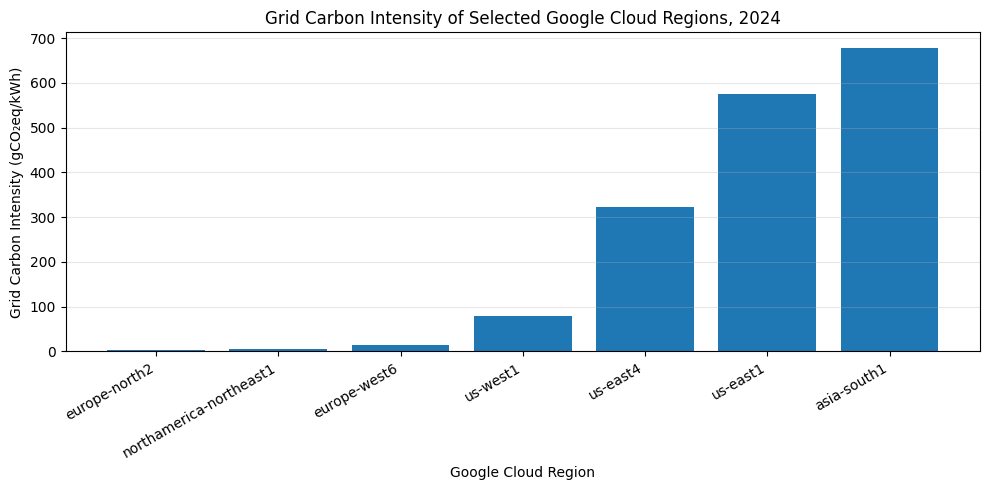

Saved figure to:
C:\Users\ZEUS\Documents\carbon_aware_marine_ai\figures\selected_gcp_regions_grid_carbon_intensity_2024.png
File exists: True


In [14]:
plt.figure(figsize=(10, 5))

plt.bar(
    selected_regions_df["cloud_region"],
    selected_regions_df["grid_carbon_intensity_gco2eq_per_kwh"]
)

plt.title("Grid Carbon Intensity of Selected Google Cloud Regions, 2024")
plt.xlabel("Google Cloud Region")
plt.ylabel("Grid Carbon Intensity (gCO₂eq/kWh)")
plt.xticks(rotation=30, ha="right")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()

figure_path = FIGURES_DIR / "selected_gcp_regions_grid_carbon_intensity_2024.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:")
print(figure_path)
print("File exists:", figure_path.exists())

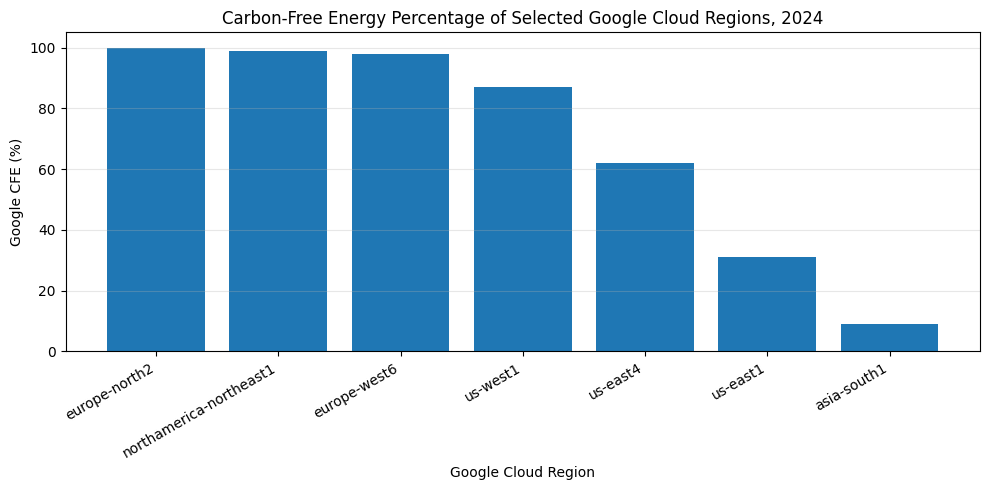

Saved figure to:
C:\Users\ZEUS\Documents\carbon_aware_marine_ai\figures\selected_gcp_regions_cfe_percent_2024.png
File exists: True


In [15]:
plt.figure(figsize=(10, 5))

plt.bar(
    selected_regions_df["cloud_region"],
    selected_regions_df["google_cfe_percent"]
)

plt.title("Carbon-Free Energy Percentage of Selected Google Cloud Regions, 2024")
plt.xlabel("Google Cloud Region")
plt.ylabel("Google CFE (%)")
plt.xticks(rotation=30, ha="right")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()

figure_path = FIGURES_DIR / "selected_gcp_regions_cfe_percent_2024.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:")
print(figure_path)
print("File exists:", figure_path.exists())

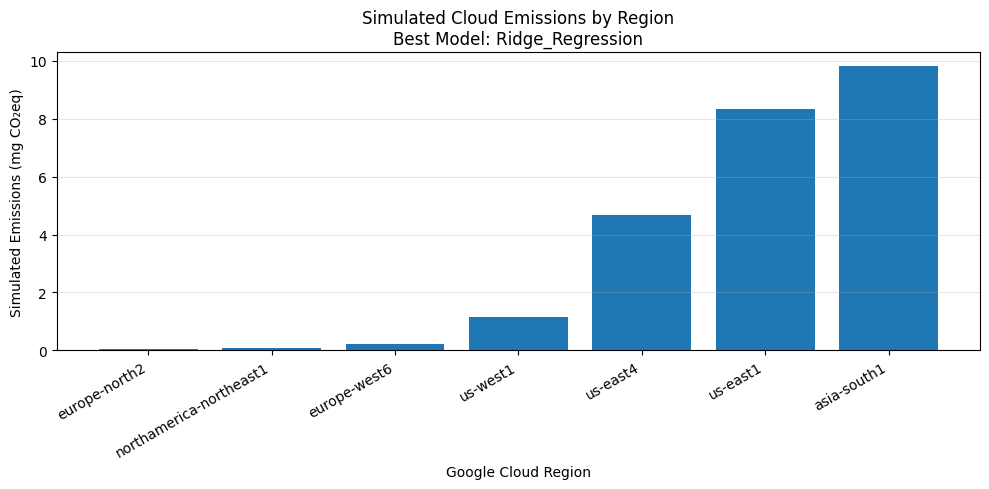

Saved figure to:
C:\Users\ZEUS\Documents\carbon_aware_marine_ai\figures\best_model_simulated_cloud_emissions_by_region.png
File exists: True


In [16]:
plt.figure(figsize=(10, 5))

plt.bar(
    best_model_cloud_df["cloud_region"],
    best_model_cloud_df["simulated_cloud_emissions_mg_co2eq"]
)

plt.title(f"Simulated Cloud Emissions by Region\nBest Model: {best_model_name}")
plt.xlabel("Google Cloud Region")
plt.ylabel("Simulated Emissions (mg CO₂eq)")
plt.xticks(rotation=30, ha="right")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()

figure_path = FIGURES_DIR / "best_model_simulated_cloud_emissions_by_region.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:")
print(figure_path)
print("File exists:", figure_path.exists())

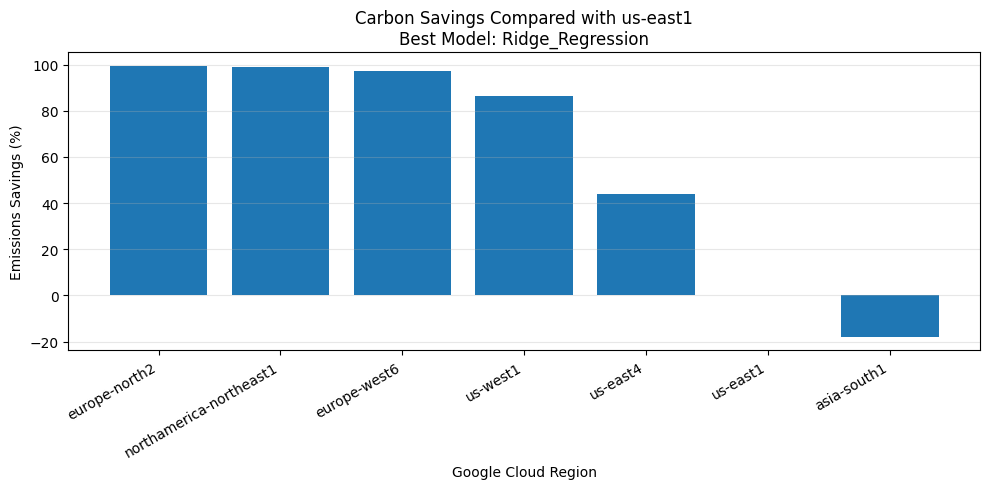

Saved figure to:
C:\Users\ZEUS\Documents\carbon_aware_marine_ai\figures\best_model_carbon_savings_vs_us_east1.png
File exists: True


In [17]:
best_model_savings_df = savings_df[
    savings_df["model"] == best_model_name
].copy()

best_model_savings_df = best_model_savings_df.sort_values(
    "emissions_savings_percent",
    ascending=False
)

plt.figure(figsize=(10, 5))

plt.bar(
    best_model_savings_df["cloud_region"],
    best_model_savings_df["emissions_savings_percent"]
)

plt.title(f"Carbon Savings Compared with {reference_region}\nBest Model: {best_model_name}")
plt.xlabel("Google Cloud Region")
plt.ylabel("Emissions Savings (%)")
plt.xticks(rotation=30, ha="right")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()

figure_path = FIGURES_DIR / "best_model_carbon_savings_vs_us_east1.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:")
print(figure_path)
print("File exists:", figure_path.exists())

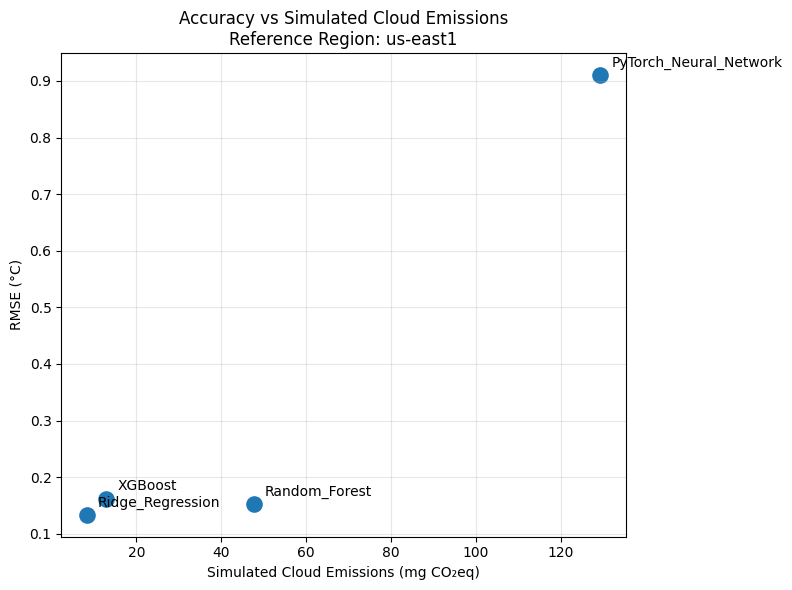

Saved figure to:
C:\Users\ZEUS\Documents\carbon_aware_marine_ai\figures\accuracy_vs_simulated_cloud_emissions_us_east1.png
File exists: True


In [18]:
reference_accuracy_emissions_df = cloud_simulation_df[
    cloud_simulation_df["cloud_region"] == reference_region
].copy()

reference_accuracy_emissions_df = reference_accuracy_emissions_df[
    reference_accuracy_emissions_df["model"] != "Persistence_Baseline"
].copy()

plt.figure(figsize=(8, 6))

plt.scatter(
    reference_accuracy_emissions_df["simulated_cloud_emissions_mg_co2eq"],
    reference_accuracy_emissions_df["rmse"],
    s=120
)

for _, row in reference_accuracy_emissions_df.iterrows():
    plt.annotate(
        row["model"],
        (row["simulated_cloud_emissions_mg_co2eq"], row["rmse"]),
        textcoords="offset points",
        xytext=(8, 6),
        ha="left"
    )

plt.title(f"Accuracy vs Simulated Cloud Emissions\nReference Region: {reference_region}")
plt.xlabel("Simulated Cloud Emissions (mg CO₂eq)")
plt.ylabel("RMSE (°C)")
plt.grid(True, alpha=0.3)
plt.tight_layout()

figure_path = FIGURES_DIR / "accuracy_vs_simulated_cloud_emissions_us_east1.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:")
print(figure_path)
print("File exists:", figure_path.exists())

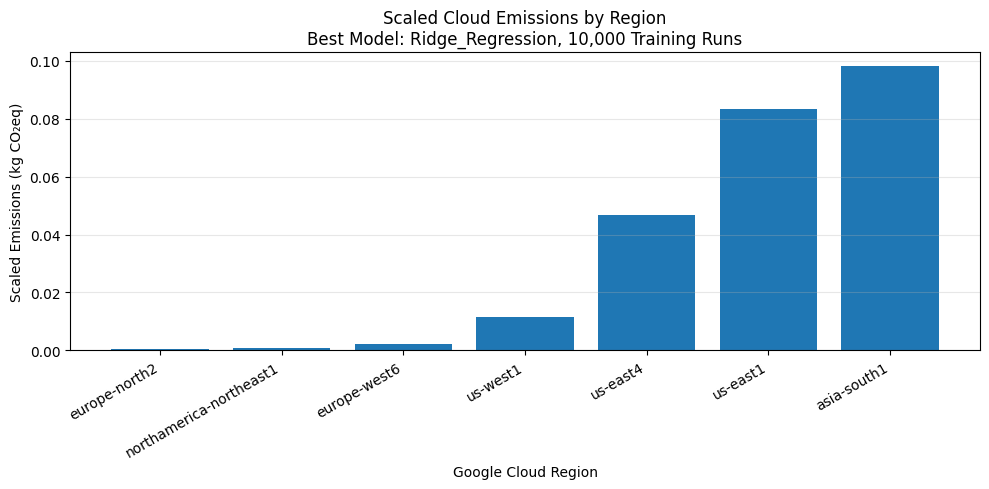

Saved figure to:
C:\Users\ZEUS\Documents\carbon_aware_marine_ai\figures\scaled_best_model_cloud_emissions_by_region.png
File exists: True


In [19]:
scaled_best_model_df = scaled_savings_df[
    scaled_savings_df["model"] == best_model_name
].copy()

scaled_best_model_df = scaled_best_model_df.sort_values(
    "scaled_cloud_emissions_kg_co2eq"
)

plt.figure(figsize=(10, 5))

plt.bar(
    scaled_best_model_df["cloud_region"],
    scaled_best_model_df["scaled_cloud_emissions_kg_co2eq"]
)

plt.title(f"Scaled Cloud Emissions by Region\nBest Model: {best_model_name}, {scale_factor:,} Training Runs")
plt.xlabel("Google Cloud Region")
plt.ylabel("Scaled Emissions (kg CO₂eq)")
plt.xticks(rotation=30, ha="right")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()

figure_path = FIGURES_DIR / "scaled_best_model_cloud_emissions_by_region.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:")
print(figure_path)
print("File exists:", figure_path.exists())

In [20]:
# Finding cleanest region for each model
best_region_per_model = (
    cloud_simulation_df
    .sort_values("simulated_cloud_emissions_kg_co2eq")
    .groupby("model", as_index=False)
    .first()
)

# Finding highest-carbon selected region for each model
worst_region_per_model = (
    cloud_simulation_df
    .sort_values("simulated_cloud_emissions_kg_co2eq", ascending=False)
    .groupby("model", as_index=False)
    .first()
)

recommendation_df = best_region_per_model[[
    "model",
    "rmse",
    "measured_energy_kwh",
    "cloud_region",
    "location",
    "google_cfe_percent",
    "grid_carbon_intensity_gco2eq_per_kwh",
    "simulated_cloud_emissions_kg_co2eq"
]].rename(columns={
    "cloud_region": "recommended_low_carbon_region",
    "location": "recommended_location",
    "google_cfe_percent": "recommended_cfe_percent",
    "grid_carbon_intensity_gco2eq_per_kwh": "recommended_grid_carbon_intensity",
    "simulated_cloud_emissions_kg_co2eq": "recommended_emissions_kg_co2eq"
})

worst_compact_df = worst_region_per_model[[
    "model",
    "cloud_region",
    "location",
    "grid_carbon_intensity_gco2eq_per_kwh",
    "simulated_cloud_emissions_kg_co2eq"
]].rename(columns={
    "cloud_region": "highest_emission_region_in_selected_set",
    "location": "highest_emission_location",
    "grid_carbon_intensity_gco2eq_per_kwh": "highest_region_grid_carbon_intensity",
    "simulated_cloud_emissions_kg_co2eq": "highest_region_emissions_kg_co2eq"
})

recommendation_df = recommendation_df.merge(
    worst_compact_df,
    on="model",
    how="left"
)

recommendation_df["potential_savings_percent_vs_highest_selected_region"] = (
    (
        recommendation_df["highest_region_emissions_kg_co2eq"]
        - recommendation_df["recommended_emissions_kg_co2eq"]
    )
    / recommendation_df["highest_region_emissions_kg_co2eq"]
) * 100

recommendation_output_path = CLOUD_SIM_DIR / "carbon_aware_cloud_region_recommendations.csv"
recommendation_df.to_csv(recommendation_output_path, index=False)

print("Cloud recommendation table saved to:")
print(recommendation_output_path)
print("File exists:", recommendation_output_path.exists())

recommendation_df

Cloud recommendation table saved to:
C:\Users\ZEUS\Documents\carbon_aware_marine_ai\outputs\cloud_simulation\carbon_aware_cloud_region_recommendations.csv
File exists: True


,model,rmse,measured_energy_kwh,recommended_low_carbon_region,recommended_location,recommended_cfe_percent,recommended_grid_carbon_intensity,recommended_emissions_kg_co2eq,highest_emission_region_in_selected_set,highest_emission_location,highest_region_grid_carbon_intensity,highest_region_emissions_kg_co2eq,potential_savings_percent_vs_highest_selected_region
0,Persistence_Baseline,0.145137,0.000000,europe-north2,Stockholm,100.0,2.73,0.000000e+00,us-east1,South Carolina,575.77,0.000000,NaN
1,PyTorch_Neural_Network,0.910292,0.000225,europe-north2,Stockholm,100.0,2.73,6.129631e-07,asia-south1,Mumbai,678.76,0.000152,99.597796
2,Random_Forest,0.152920,0.000083,europe-north2,Stockholm,100.0,2.73,2.259362e-07,asia-south1,Mumbai,678.76,0.000056,99.597796
3,Ridge_Regression,0.133645,0.000014,europe-north2,Stockholm,100.0,2.73,3.947131e-08,asia-south1,Mumbai,678.76,0.000010,99.597796
4,XGBoost,0.162210,0.000022,europe-north2,Stockholm,100.0,2.73,6.129950e-08,asia-south1,Mumbai,678.76,0.000015,99.597796


In [21]:
best_model_row = model_metrics_df.sort_values("rmse").iloc[0]

best_model_best_region = best_model_cloud_df.iloc[0]
best_model_reference_region = best_model_cloud_df[
    best_model_cloud_df["cloud_region"] == reference_region
].iloc[0]

best_model_savings_vs_reference_percent = (
    (
        best_model_reference_region["simulated_cloud_emissions_kg_co2eq"]
        - best_model_best_region["simulated_cloud_emissions_kg_co2eq"]
    )
    / best_model_reference_region["simulated_cloud_emissions_kg_co2eq"]
) * 100

cloud_experiment_summary = {
    "project_title": "Carbon-Aware Cloud Computing for AI in Marine Research",
    "case_study_region": "South Florida Atlantic Coast",
    "best_model_by_accuracy": best_model_row["model"],
    "best_model_rmse": best_model_row["rmse"],
    "best_model_mae": best_model_row["mae"],
    "best_model_r2": best_model_row["r2"],
    "best_model_measured_energy_kwh": best_model_best_region["measured_energy_kwh"],
    "reference_cloud_region": reference_region,
    "recommended_low_carbon_region": best_model_best_region["cloud_region"],
    "recommended_low_carbon_location": best_model_best_region["location"],
    "recommended_region_cfe_percent": best_model_best_region["google_cfe_percent"],
    "recommended_region_grid_carbon_intensity_gco2eq_per_kwh": best_model_best_region["grid_carbon_intensity_gco2eq_per_kwh"],
    "best_model_emissions_in_reference_region_kg_co2eq": best_model_reference_region["simulated_cloud_emissions_kg_co2eq"],
    "best_model_emissions_in_recommended_region_kg_co2eq": best_model_best_region["simulated_cloud_emissions_kg_co2eq"],
    "best_model_savings_vs_reference_percent": best_model_savings_vs_reference_percent,
    "scaled_scenario_training_runs": scale_factor
}

cloud_experiment_summary_df = pd.DataFrame([cloud_experiment_summary])

summary_output_path = OUTPUTS_DIR / "cloud_carbon_experiment_summary_south_florida_atlantic_2021_2024.csv"
cloud_experiment_summary_df.to_csv(summary_output_path, index=False)

print("Cloud carbon experiment summary saved to:")
print(summary_output_path)
print("File exists:", summary_output_path.exists())

cloud_experiment_summary_df

Cloud carbon experiment summary saved to:
C:\Users\ZEUS\Documents\carbon_aware_marine_ai\outputs\cloud_carbon_experiment_summary_south_florida_atlantic_2021_2024.csv
File exists: True


,project_title,case_study_region,best_model_by_accuracy,best_model_rmse,best_model_mae,best_model_r2,best_model_measured_energy_kwh,reference_cloud_region,recommended_low_carbon_region,recommended_low_carbon_location,recommended_region_cfe_percent,recommended_region_grid_carbon_intensity_gco2eq_per_kwh,best_model_emissions_in_reference_region_kg_co2eq,best_model_emissions_in_recommended_region_kg_co2eq,best_model_savings_vs_reference_percent,scaled_scenario_training_runs
0,Carbon-Aware Cloud Computing for AI in Marine ...,South Florida Atlantic Coast,Ridge_Regression,0.133645,0.098404,0.995755,0.000014,us-east1,europe-north2,Stockholm,100.0,2.73,0.000008,3.947131e-08,99.525852,10000


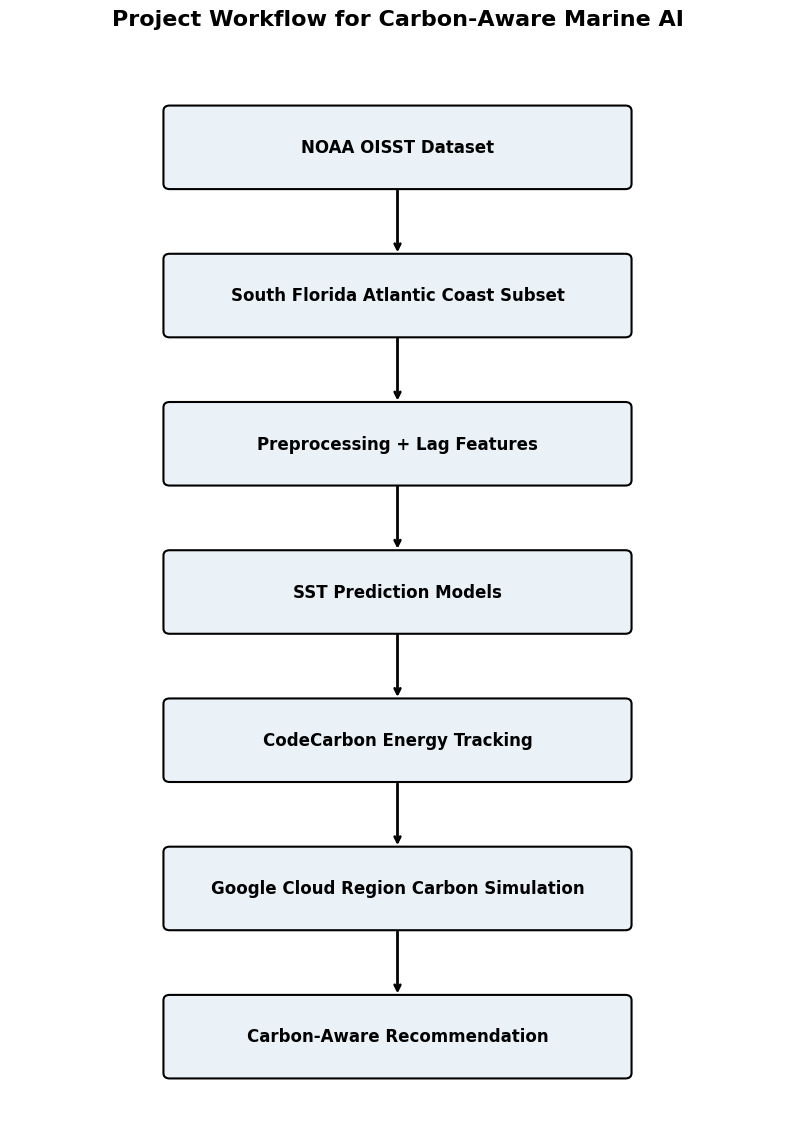

Saved figure to:
C:\Users\ZEUS\Documents\carbon_aware_marine_ai\figures\project_workflow_diagram_carbon_aware_marine_ai.png
File exists: True


In [22]:
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# Fixed project root
PROJECT_ROOT = Path(r"C:\Users\ZEUS\Documents\carbon_aware_marine_ai")
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Workflow steps
workflow_steps = [
    "NOAA OISST Dataset",
    "South Florida Atlantic Coast Subset",
    "Preprocessing + Lag Features",
    "SST Prediction Models",
    "CodeCarbon Energy Tracking",
    "Google Cloud Region Carbon Simulation",
    "Carbon-Aware Recommendation"
]

# Creating the figure
fig, ax = plt.subplots(figsize=(10, 14))
ax.set_xlim(0, 10)
ax.set_ylim(0, 16)
ax.axis("off")

# Box settings
box_x = 2
box_width = 6
box_height = 1.2
start_y = 14
gap = 1.0

# Storing box center positions for arrows
box_centers = []

# Drawing boxes
for i, step in enumerate(workflow_steps):
    y = start_y - i * (box_height + gap)

    box = FancyBboxPatch(
        (box_x, y),
        box_width,
        box_height,
        boxstyle="round,pad=0.02,rounding_size=0.08",
        linewidth=1.5,
        edgecolor="black",
        facecolor="#eaf2f8"
    )
    ax.add_patch(box)

    ax.text(
        box_x + box_width / 2,
        y + box_height / 2,
        step,
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold"
    )

    box_centers.append((box_x + box_width / 2, y, y + box_height))

# Drawing arrows between boxes
for i in range(len(box_centers) - 1):
    x_center = box_centers[i][0]
    current_bottom = box_centers[i][1]
    next_top = box_centers[i + 1][2]

    ax.annotate(
        "",
        xy=(x_center, next_top),
        xytext=(x_center, current_bottom),
        arrowprops=dict(arrowstyle="->", lw=2)
    )

# Title
ax.set_title(
    "Project Workflow for Carbon-Aware Marine AI",
    fontsize=16,
    fontweight="bold",
    pad=20
)

# Saving the figure
figure_path = FIGURES_DIR / "project_workflow_diagram_carbon_aware_marine_ai.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure to:")
print(figure_path)
print("File exists:", figure_path.exists())